# Import modules

In [1]:
import numpy as np
import pandas as pd
import scipy.signal
import geopandas as gpd
import datetime
import matplotlib.pyplot as plt

from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Clark unit hydrograph

In [2]:
site = 'Tenmile_Ck_S010'
reach_id = '517345'
time_of_concentration = 7.44
storage_coeff = 4.49

In [3]:
def clark_integral_hydrograph(t, t_c):
    if (t <= 0.):
        result = 0.
    elif (t > 0.) and (t <= t_c / 2):
        result = np.sqrt(2) * (t / t_c)**(1.5)
    elif (t > t_c / 2) and (t < t_c):
        result = 1. - np.sqrt(2) * (1 - t / t_c)**(1.5)
    else:
        result = 1.
    return result

def clark_unit_hydrograph(t, t_c):
    if (t <= 0.):
        result = 0.
    elif (t > 0.) and (t <= t_c / 2):
        result = (3 * np.sqrt(2)) / (2 * t_c**(1.5)) * np.sqrt(t)
    elif (t > t_c / 2) and (t < t_c):
        result = 3 * np.sqrt(1 - t / t_c) / (np.sqrt(2) * t_c)
    else:
        result = 0.
    return result

In [4]:
t_min = 0.
t_max = 20.
n_steps = 2000
t_ord, dt = np.linspace(t_min, t_max, n_steps, retstep=True)
uh = pd.Series({t : clark_unit_hydrograph(t, time_of_concentration) for t in t_ord})
uh /= np.trapezoid(uh.values, uh.index)

Text(0, 0.5, 'Unit hydrograph value [-]')

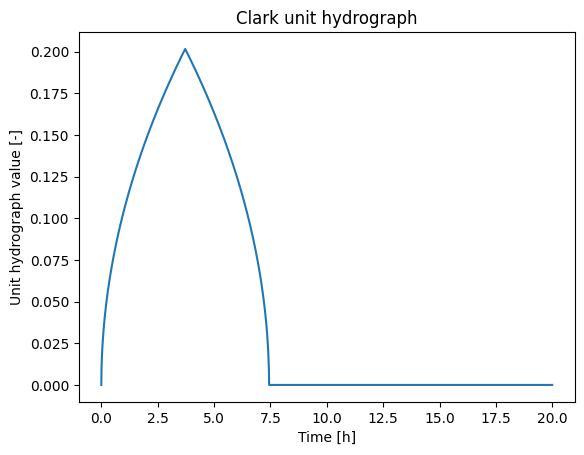

In [5]:
plt.plot(uh.index, uh.values)
plt.title('Clark unit hydrograph')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph value [-]')

In [6]:
R = storage_coeff
C_a = dt / (R + 2 * dt)
C_b = 1 - C_a
k, Y = scipy.signal.dlti(C_b, C_a, 1., 0.).impulse(t=np.arange(n_steps))
t = dt * k
y = (Y[0] / dt).ravel()
y /= np.trapezoid(y, t)
y = pd.Series(y, index=t)

Text(0, 0.5, 'Unit hydrograph value [-]')

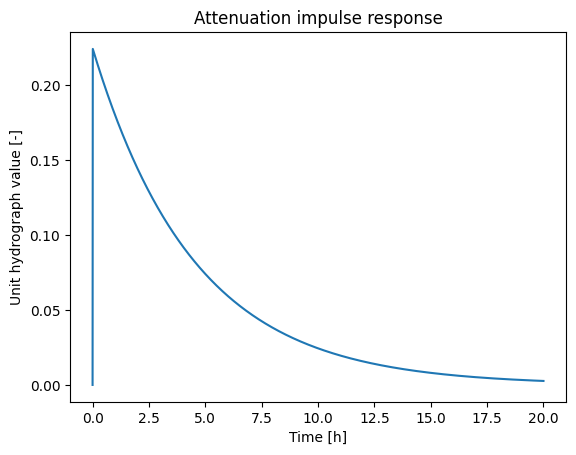

In [7]:
plt.plot(y.index, y.values)
plt.title('Attenuation impulse response')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph value [-]')

In [8]:
assert (y.index == uh.index).all()

In [9]:
travel_time = np.convolve(uh.values, y.values)
travel_time = pd.Series(travel_time, index=(dt * np.arange(len(travel_time))))
travel_time /= np.trapezoid(travel_time.values, travel_time.index)

Text(0, 0.5, 'Unit hydrograph [-]')

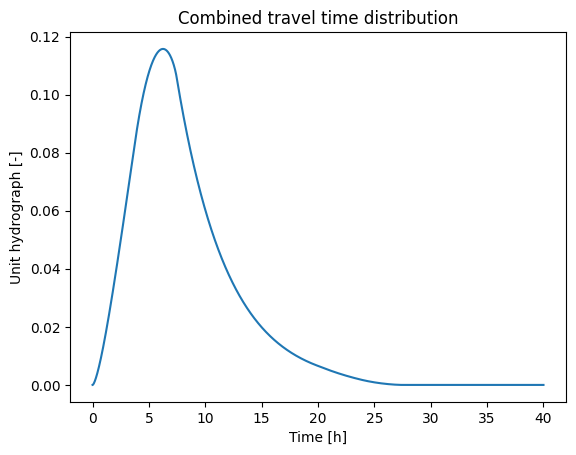

In [10]:
travel_time.plot()
plt.title('Combined travel time distribution')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph [-]')

# Instantiate Muskingum model

In [11]:
model_collection = ModelCollection.from_file('../data/trinity_muskingum.json')
model = model_collection.models['dfw']

model.timedelta = pd.Timedelta(dt * 3600, unit='s')
model.compute_muskingum_coeffs()
model.save_state()

o_t = np.zeros(model.n)
model.init_states(o_t_next=o_t)

# Add downstream boundaries to model
for model in model_collection.models.values():
    for outlet in model.startnodes[model.startnodes == model.endnodes]:
        model.set_transmissive_boundary(outlet)

outputs = {}

n_steps = len(travel_time) - 1
impulse_active = True
# Step model forward in time
for i in range(n_steps):
    o_t = model.o_t
    outputs[i] = o_t
    if impulse_active:
        p_t_next = np.ones(model.n)
        impulse_active = False
    else:
        p_t_next = np.zeros(model.n)
    model.step(p_t_next)

outputs = pd.DataFrame.from_dict(outputs, orient='index')
outputs.columns = model.reach_ids

In [12]:
outlet = outputs[reach_id]
outlet.index *= dt
outlet /= np.trapezoid(outlet.values, outlet.index)

Text(0, 0.5, 'Unit hydrograph [-]')

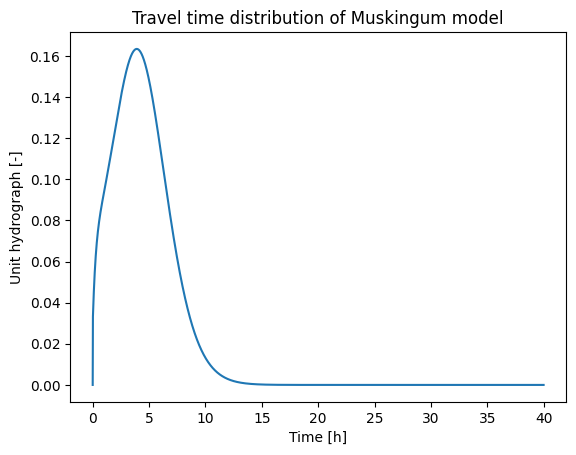

In [13]:
plt.plot(outlet.index, outlet.values)
plt.title('Travel time distribution of Muskingum model')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph [-]')

# Comparison between Clark Hydrograph and Muskingum

Text(0, 0.5, 'Unit hydrograph [-]')

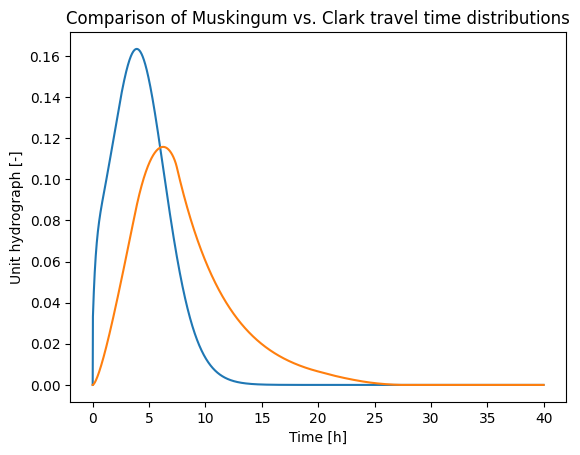

In [14]:
plt.plot(outlet.index, outlet.values)
plt.plot(travel_time.index, travel_time.values)
#plt.axvline(4, c='k', linestyle='--')
#plt.axvline(6.25, c='k', linestyle='--')
plt.title('Comparison of Muskingum vs. Clark travel time distributions')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph [-]')


# For now, just adjust K and X to match

In [15]:
model_collection = ModelCollection.from_file('../data/trinity_muskingum.json')
model = model_collection.models['dfw']

model.timedelta = pd.Timedelta(dt * 3600, unit='s')
model.K *= 6.25 / 4.
model.X = np.minimum(1.35 * model.X, 0.5)
model.compute_muskingum_coeffs()
model.save_state()

o_t = np.zeros(model.n)
model.init_states(o_t_next=o_t)

# Add downstream boundaries to model
for model in model_collection.models.values():
    for outlet in model.startnodes[model.startnodes == model.endnodes]:
        model.set_transmissive_boundary(outlet)

outputs = {}

n_steps = len(travel_time) - 1
impulse_active = True
# Step model forward in time
for i in range(n_steps):
    o_t = model.o_t
    outputs[i] = o_t
    if impulse_active:
        p_t_next = np.ones(model.n)
        impulse_active = False
    else:
        p_t_next = np.zeros(model.n)
    model.step(p_t_next)

outputs = pd.DataFrame.from_dict(outputs, orient='index')
outputs.columns = model.reach_ids


In [16]:
outlet = outputs[reach_id]
outlet.index *= dt
outlet /= np.trapezoid(outlet.values, outlet.index)

Text(0, 0.5, 'Unit hydrograph [-]')

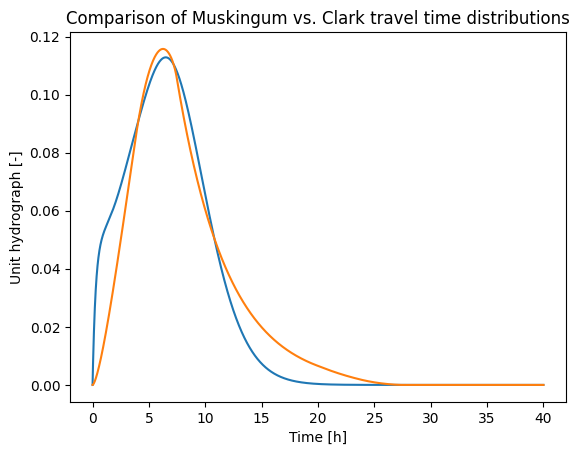

In [17]:
plt.plot(outlet.index, outlet.values)
plt.plot(travel_time.index, travel_time.values)
plt.title('Comparison of Muskingum vs. Clark travel time distributions')
plt.xlabel('Time [h]')
plt.ylabel('Unit hydrograph [-]')
